# EV Telemetry — Phase 3 Dataset Exploration Notebook

This notebook is a **hands-on debugging + evidence builder** for your EV telemetry dataset.

You can:
- Load gold window features or the Phase 3 debug CSV outputs
- Compute quality + consistency checks
- Find constant / near-constant signals
- Inspect worst trips / worst rows
- Generate plots suitable for sharing with founders / hardware teams

> Tip: Start by running cells top-to-bottom. You only need to edit the **Config** cell.


In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# ============================
# CONFIG (edit these paths)
# ============================

# Option A: analyze Phase 3 debug outputs (recommended, fast)
PHASE3_DIR = Path("models/phase3_debug")  # folder created by training/run_phase3_debug.py

VAL_PRED_CSV = PHASE3_DIR / "val_predictions_debug.csv"
FEATURE_CONST_CSV = PHASE3_DIR / "feature_constant_report.csv"
VAL_PER_TRIP_CSV = PHASE3_DIR / "val_per_trip_mae.csv"
FEATURE_IMPORTANCE_CSV = PHASE3_DIR / "feature_importance.csv"
REPORT_JSON = PHASE3_DIR / "report.json"

# Option B: analyze gold window_features directly (slower)
# Example: data/gold/window_features/dt=2026-02-23/vehicle_id=EV01/*.parquet
GOLD_BASE = Path("data/gold/window_features")
TRAIN_DT = "2026-02-23"
VEHICLE_ID = "EV01"

# Focus trip (update as needed)
FOCUS_TRIP = "EV01_000302"

print("Config loaded.")
print("VAL_PRED_CSV exists:", VAL_PRED_CSV.exists())


Config loaded.
VAL_PRED_CSV exists: True


In [2]:
import json
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

def show(df, n=5):
    display(df.head(n))


In [3]:
# ============================
# Load Phase 3 Debug Outputs
# ============================

assert VAL_PRED_CSV.exists(), f"Missing {VAL_PRED_CSV}. Run: python training/run_phase3_debug.py"

val = pd.read_csv(VAL_PRED_CSV)
val["timestamp"] = pd.to_datetime(val["timestamp"], utc=True, errors="coerce")

# Ensure error columns exist
if "error" not in val.columns and ("pred" in val.columns and "y_soc_t_plus_300s" in val.columns):
    val["error"] = val["pred"] - val["y_soc_t_plus_300s"]
if "abs_error" not in val.columns and "error" in val.columns:
    val["abs_error"] = val["error"].abs()

print("Loaded:", len(val), "rows")
print("Trips:", val["trip_id"].nunique())
show(val, 3)


Loaded: 2930 rows
Trips: 20


,timestamp,trip_id,soc_pct,y_soc_t_plus_300s,battery_current_a,output_power_kw,motor_speed_rpm,quality_flag,pred,error,abs_error
0,2026-02-17 06:48:50+00:00,EV01_000251,61.0,61.0,12.0,6.995,897.0,2,59.767246,-1.232754,1.232754
1,2026-02-17 06:48:52+00:00,EV01_000251,61.0,61.0,12.0,6.996,901.0,2,59.758300,-1.241699,1.241699
2,2026-02-17 06:48:54+00:00,EV01_000251,61.0,61.0,12.0,6.996,899.0,2,59.758300,-1.241699,1.241699


In [4]:
# ============================
# Quick Summary (Founder-friendly numbers)
# ============================

print("Rows:", len(val))
print("Trips:", val["trip_id"].nunique())
print("Abs error summary:")
display(val["abs_error"].describe().round(3))

# Tail error counts
for thr in [0.5, 1.0, 2.0, 3.0, 4.0]:
    pct = (val["abs_error"] >= thr).mean() * 100
    print(f"% rows with |error| >= {thr:.1f}% SOC: {pct:.2f}%")


Rows: 2930
Trips: 20
Abs error summary:


count    2930.000
mean        0.441
std         0.483
min         0.000
25%         0.143
50%         0.286
75%         0.598
max         4.571
Name: abs_error, dtype: float64

% rows with |error| >= 0.5% SOC: 30.96%
% rows with |error| >= 1.0% SOC: 9.39%
% rows with |error| >= 2.0% SOC: 1.33%
% rows with |error| >= 3.0% SOC: 0.34%
% rows with |error| >= 4.0% SOC: 0.27%


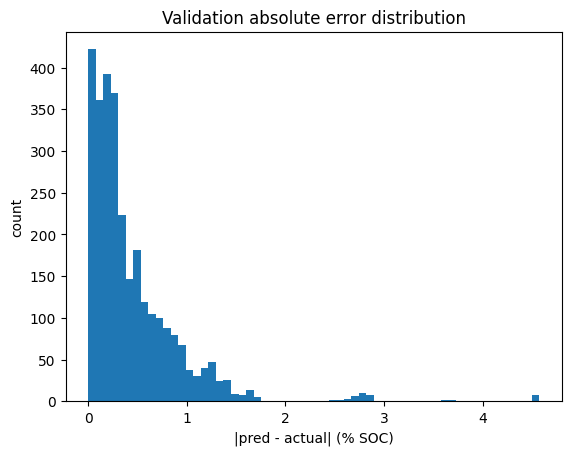

In [5]:
# ============================
# Plot: Error distribution
# ============================
plt.figure()
plt.hist(val["abs_error"].dropna(), bins=60)
plt.xlabel("|pred - actual| (% SOC)")
plt.ylabel("count")
plt.title("Validation absolute error distribution")
plt.show()


,trip_id,rows,mae,p95,max_abs,soc_min,soc_max,soc_range
15,EV01_000302,181,1.023853,3.657101,4.571396,65.0,71.0,65.0–71.0%
17,EV01_000305,103,0.671639,1.295763,1.400970,73.0,79.0,73.0–79.0%
11,EV01_000297,40,0.657820,1.060393,1.080803,80.0,82.0,80.0–82.0%
4,EV01_000281,28,0.627316,0.658458,0.683639,99.0,99.0,99.0–99.0%
13,EV01_000300,153,0.595283,1.425392,1.477448,89.0,95.0,89.0–95.0%
2,EV01_000276,167,0.555048,1.238087,1.284615,89.0,99.0,89.0–99.0%
18,EV01_000306,24,0.543190,0.858191,0.888687,68.0,68.0,68.0–68.0%
10,EV01_000296,26,0.541307,0.612160,0.617813,84.0,84.0,84.0–84.0%
9,EV01_000295,235,0.506472,1.147614,1.443138,88.0,94.0,88.0–94.0%
0,EV01_000251,48,0.504548,1.241699,1.279320,51.0,61.0,51.0–61.0%


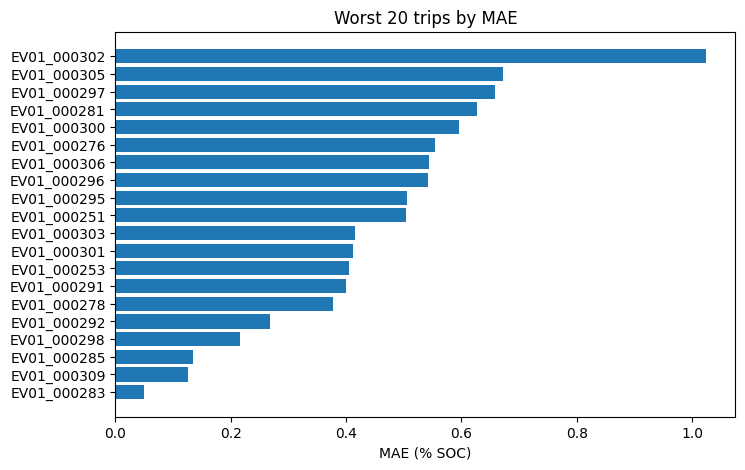

Worst trip: EV01_000302 MAE= 1.024


In [6]:
# ============================
# Per-trip error table + plot
# ============================
per_trip = (
    val.groupby("trip_id", as_index=False)
       .agg(rows=("abs_error", "size"),
            mae=("abs_error", "mean"),
            p95=("abs_error", lambda s: np.quantile(s, 0.95)),
            max_abs=("abs_error", "max"),
            soc_min=("soc_pct", "min"),
            soc_max=("soc_pct", "max"))
       .sort_values("mae", ascending=False)
)

per_trip["soc_range"] = per_trip["soc_min"].round(1).astype(str) + "–" + per_trip["soc_max"].round(1).astype(str) + "%"

display(per_trip.head(20))

# Plot worst 20 trips by MAE
top = per_trip.head(20).sort_values("mae")
plt.figure(figsize=(8,5))
plt.barh(top["trip_id"], top["mae"])
plt.xlabel("MAE (% SOC)")
plt.title("Worst 20 trips by MAE")
plt.show()

print("Worst trip:", per_trip.iloc[0]["trip_id"], "MAE=", round(per_trip.iloc[0]["mae"],3))


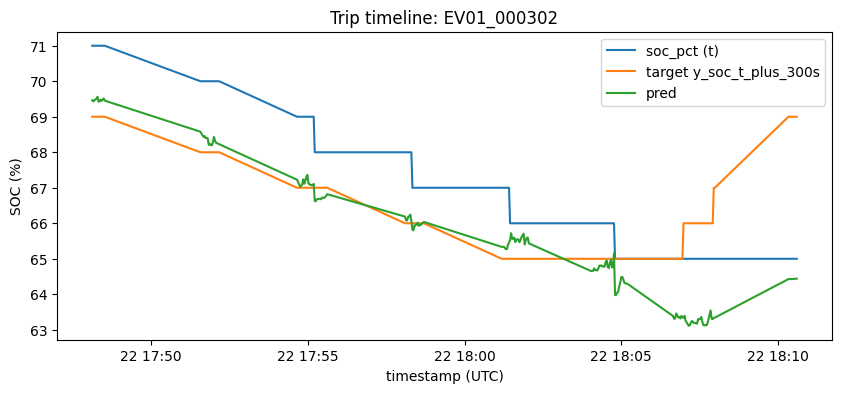

In [8]:
# ============================
# Focus Trip: SOC + target + prediction timeline
# ============================
g = val[val["trip_id"] == FOCUS_TRIP].copy()
assert len(g) > 0, f"FOCUS_TRIP not found: {FOCUS_TRIP}"

g = g.sort_values("timestamp")
ycol = "y_soc_t_plus_300s"
assert ycol in g.columns, f"Missing {ycol} in val_predictions_debug.csv"

plt.figure(figsize=(10,4))
plt.plot(g["timestamp"], g["soc_pct"], label="soc_pct (t)")
plt.plot(g["timestamp"], g[ycol], label="target y_soc_t_plus_300s")
plt.plot(g["timestamp"], g["pred"], label="pred")
plt.xlabel("timestamp (UTC)")
plt.ylabel("SOC (%)")
plt.title(f"Trip timeline: {FOCUS_TRIP}")
plt.legend()
plt.show()


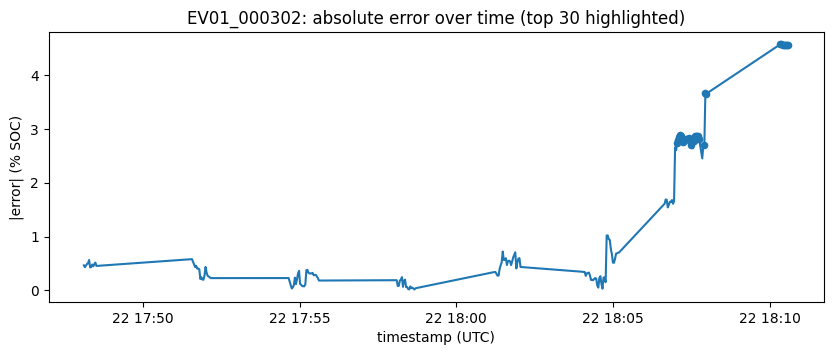

In [9]:
# ============================
# Focus Trip: absolute error over time (top 30 highlighted)
# ============================
g = g.copy()
plt.figure(figsize=(10,3.5))
plt.plot(g["timestamp"], g["abs_error"])
worst = g.nlargest(30, "abs_error")
plt.scatter(worst["timestamp"], worst["abs_error"], s=20)
plt.xlabel("timestamp (UTC)")
plt.ylabel("|error| (% SOC)")
plt.title(f"{FOCUS_TRIP}: absolute error over time (top 30 highlighted)")
plt.show()


Missing columns: []
Suspicious rows (speed>300 rpm AND (power~0 OR current~0)): 99


,timestamp,trip_id,soc_pct,y_soc_t_plus_300s,pred,error,battery_current_a,output_power_kw,motor_speed_rpm,quality_flag
1851,2026-02-22 18:10:20+00:00,EV01_000302,65.0,69.0,64.428604,-4.571396,0.0,0.0,874.00000,0
1852,2026-02-22 18:10:22+00:00,EV01_000302,65.0,69.0,64.428604,-4.571396,0.0,0.0,874.00000,0
1855,2026-02-22 18:10:30+00:00,EV01_000302,65.0,69.0,64.429794,-4.570206,0.0,0.0,874.00000,0
1854,2026-02-22 18:10:28+00:00,EV01_000302,65.0,69.0,64.429794,-4.570206,0.0,0.0,874.00000,0
1853,2026-02-22 18:10:26+00:00,EV01_000302,65.0,69.0,64.429794,-4.570206,0.0,0.0,874.00000,0
1858,2026-02-22 18:10:36+00:00,EV01_000302,65.0,69.0,64.439644,-4.560356,0.0,0.0,874.00000,0
1856,2026-02-22 18:10:32+00:00,EV01_000302,65.0,69.0,64.439644,-4.560356,0.0,0.0,874.00000,0
1857,2026-02-22 18:10:34+00:00,EV01_000302,65.0,69.0,64.439644,-4.560356,0.0,0.0,874.00000,0
913,2026-02-21 23:46:49+00:00,EV01_000295,88.0,88.0,87.150800,-0.849197,0.0,0.0,880.00000,0
914,2026-02-21 23:46:55+00:00,EV01_000295,88.0,88.0,87.164820,-0.835182,0.0,0.0,880.00000,0


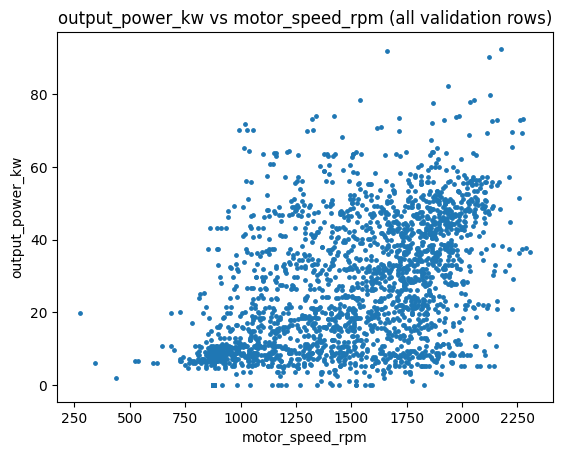

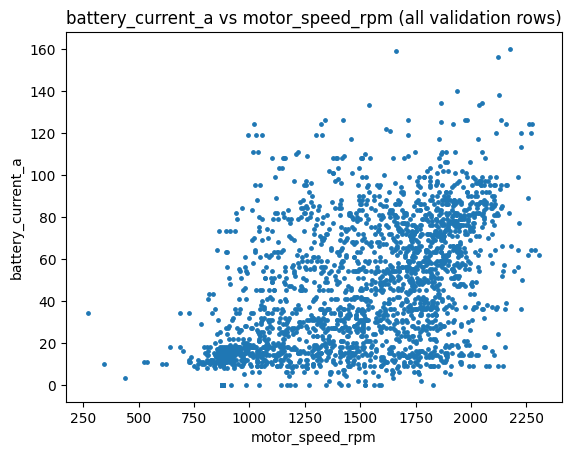

In [10]:
# ============================
# Sensor consistency checks (physics sanity)
# ============================
# These checks are NOT about ML. They find physically suspicious rows.

required = ["motor_speed_rpm", "output_power_kw", "battery_current_a"]
missing = [c for c in required if c not in val.columns]
print("Missing columns:", missing)

dfc = val.copy()

# Rule examples (tune thresholds to your system)
dfc["speed_nonzero"] = dfc.get("motor_speed_rpm", 0) > 300
dfc["power_zeroish"] = dfc.get("output_power_kw", 0).abs() < 0.1
dfc["current_zeroish"] = dfc.get("battery_current_a", 0).abs() < 0.1

# Suspicious: moving but no power/current
susp = dfc[dfc["speed_nonzero"] & (dfc["power_zeroish"] | dfc["current_zeroish"])].copy()
print("Suspicious rows (speed>300 rpm AND (power~0 OR current~0)):", len(susp))

# Show worst-error suspicious rows
cols = [c for c in ["timestamp","trip_id","soc_pct","y_soc_t_plus_300s","pred","error","battery_current_a","output_power_kw","motor_speed_rpm","quality_flag"] if c in susp.columns]
display(susp.sort_values("abs_error", ascending=False).head(25)[cols])

# Plot scatter: power vs speed (all val)
if "motor_speed_rpm" in val.columns and "output_power_kw" in val.columns:
    plt.figure()
    plt.scatter(val["motor_speed_rpm"], val["output_power_kw"], s=6)
    plt.xlabel("motor_speed_rpm")
    plt.ylabel("output_power_kw")
    plt.title("output_power_kw vs motor_speed_rpm (all validation rows)")
    plt.show()

# Plot scatter: current vs speed (all val)
if "motor_speed_rpm" in val.columns and "battery_current_a" in val.columns:
    plt.figure()
    plt.scatter(val["motor_speed_rpm"], val["battery_current_a"], s=6)
    plt.xlabel("motor_speed_rpm")
    plt.ylabel("battery_current_a")
    plt.title("battery_current_a vs motor_speed_rpm (all validation rows)")
    plt.show()


Rows where SOC increases > 2% over 5 minutes: 8


,timestamp,trip_id,soc_pct,y_soc_t_plus_300s,delta_soc_5m,battery_current_a,output_power_kw,motor_speed_rpm,quality_flag
1851,2026-02-22 18:10:20+00:00,EV01_000302,65.0,69.0,4.0,0.0,0.0,874.0,0
1852,2026-02-22 18:10:22+00:00,EV01_000302,65.0,69.0,4.0,0.0,0.0,874.0,0
1853,2026-02-22 18:10:26+00:00,EV01_000302,65.0,69.0,4.0,0.0,0.0,874.0,0
1854,2026-02-22 18:10:28+00:00,EV01_000302,65.0,69.0,4.0,0.0,0.0,874.0,0
1855,2026-02-22 18:10:30+00:00,EV01_000302,65.0,69.0,4.0,0.0,0.0,874.0,0
1856,2026-02-22 18:10:32+00:00,EV01_000302,65.0,69.0,4.0,0.0,0.0,874.0,0
1857,2026-02-22 18:10:34+00:00,EV01_000302,65.0,69.0,4.0,0.0,0.0,874.0,0
1858,2026-02-22 18:10:36+00:00,EV01_000302,65.0,69.0,4.0,0.0,0.0,874.0,0


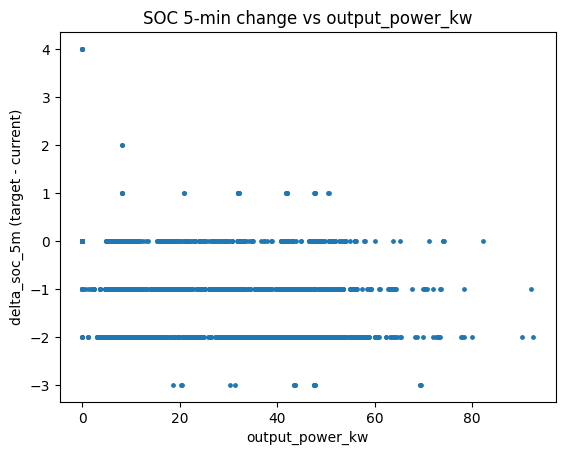

In [11]:
# ============================
# SOC jump checks (sudden SOC change without matching power)
# ============================
df = val.sort_values(["trip_id","timestamp"]).copy()

# Approximate 5-minute SOC delta (target - current)
if "y_soc_t_plus_300s" in df.columns and "soc_pct" in df.columns:
    df["delta_soc_5m"] = df["y_soc_t_plus_300s"] - df["soc_pct"]
else:
    df["delta_soc_5m"] = np.nan

# Large positive jumps
jumps = df[df["delta_soc_5m"] > 2.0].copy()
print("Rows where SOC increases > 2% over 5 minutes:", len(jumps))

cols = [c for c in ["timestamp","trip_id","soc_pct","y_soc_t_plus_300s","delta_soc_5m","battery_current_a","output_power_kw","motor_speed_rpm","quality_flag"] if c in jumps.columns]
display(jumps.sort_values("delta_soc_5m", ascending=False).head(25)[cols])

# Scatter: SOC jump vs power
if "output_power_kw" in df.columns:
    plt.figure()
    plt.scatter(df["output_power_kw"], df["delta_soc_5m"], s=6)
    plt.xlabel("output_power_kw")
    plt.ylabel("delta_soc_5m (target - current)")
    plt.title("SOC 5-min change vs output_power_kw")
    plt.show()


In [12]:
# ============================
# Constant / near-constant feature report (from CSV if available)
# ============================
if FEATURE_CONST_CSV.exists():
    rep = pd.read_csv(FEATURE_CONST_CSV)
    display(rep.sort_values(["is_constant","zero_pct"], ascending=[False, False]).head(30))

    # quick list of constant columns
    const_cols = rep[rep["is_constant"] == True]["col"].tolist()
    print("Constant columns:", const_cols)
else:
    print("Missing:", FEATURE_CONST_CSV)


,col,status,n_unique,min,max,mean,std,zero_pct,is_constant,is_near_constant
0,motor_temperature_c,ok,1,0.00000,0.000000,0.000000,0.000000,1.000000,True,True
1,motor_temperature_c_lag_300s,ok,1,0.00000,0.000000,0.000000,0.000000,1.000000,True,True
2,motor_temperature_c_roll_mean_300s,ok,1,0.00000,0.000000,0.000000,0.000000,1.000000,True,True
3,motor_temperature_c_roll_std_60s,ok,1,0.00000,0.000000,0.000000,0.000000,1.000000,True,True
4,fault_any,ok,2,0.00000,1.000000,0.097863,0.297130,0.902137,False,False
5,soc_pct_roll_std_60s,ok,31110,0.00000,0.500000,0.101948,0.181577,0.744319,False,False
6,soc_pct_roll_std_300s,ok,117203,0.00000,5.203216,0.437178,0.390663,0.271474,False,False
7,motor_speed_rpm_roll_std_60s,ok,133516,0.00000,661.976747,160.211616,167.252018,0.194583,False,False
8,avg_battery_temp_c_roll_std_300s,ok,124132,0.00000,7.100000,0.615554,1.056908,0.131895,False,False
9,battery_current_a_roll_min_60s,ok,169,0.00000,149.000000,20.763970,33.662202,0.118916,False,False


Constant columns: ['motor_temperature_c', 'motor_temperature_c_lag_300s', 'motor_temperature_c_roll_mean_300s', 'motor_temperature_c_roll_std_60s']


In [14]:
# ============================
# Feature importance (from CSV if available)
# ============================
if FEATURE_IMPORTANCE_CSV.exists():
    imp = pd.read_csv(FEATURE_IMPORTANCE_CSV)
    display(imp.head(25))

    top = imp.head(20).sort_values("importance")
    plt.figure(figsize=(8,5))
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("importance")
    plt.title("Top 20 feature importances (XGBoost)")
    plt.show()
else:
    print("Missing:", FEATURE_IMPORTANCE_CSV)


,Unnamed: 0,importance
0,soc_pct,0.570809
1,soc_pct_roll_mean_60s,0.375106
2,soc_pct_lag_60s,0.011688
3,stack_voltage_v,0.008329
4,soc_pct_lag_300s,0.003667
5,motor_speed_rpm_roll_std_60s,0.002936
6,elec_power_kw_proxy,0.002418
7,soc_pct_lag_600s,0.002070
8,battery_current_a,0.002035
9,output_power_kw,0.001934


KeyError: 'feature'

<Figure size 800x500 with 0 Axes>

## Optional: Load Gold Window Features Directly (Parquet)

If you want to explore the raw gold dataset (not just val predictions), run the cells below.

This is useful for:
- Checking constant columns in the full dataset
- Plotting distributions of signals
- Comparing train vs validation distributions


In [18]:
import glob

def load_gold_parts(dt: str, vehicle_id: str, max_parts: int | None = None, columns: list[str] | None = None):
    base = GOLD_BASE / f"dt={dt}" / f"vehicle_id={vehicle_id}"
    parts = sorted(list(base.glob("*.parquet")))
    if max_parts is not None:
        parts = parts[:max_parts]
    if len(parts) == 0:
        raise FileNotFoundError(f"No parquet parts found under: {base}")
    frames = []
    for p in parts:
        frames.append(pd.read_parquet(p, columns=columns))
    return pd.concat(frames, ignore_index=True)

# Example load (first 5 parts to keep it fast)
df_gold = load_gold_parts(TRAIN_DT, VEHICLE_ID, max_parts=5)
print(df_gold.shape)


(79399, 356)


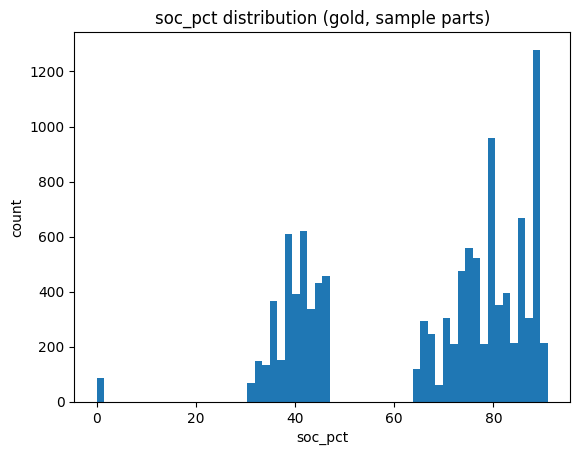

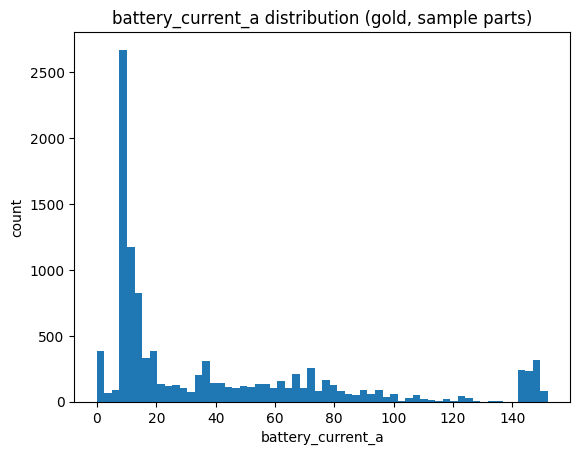

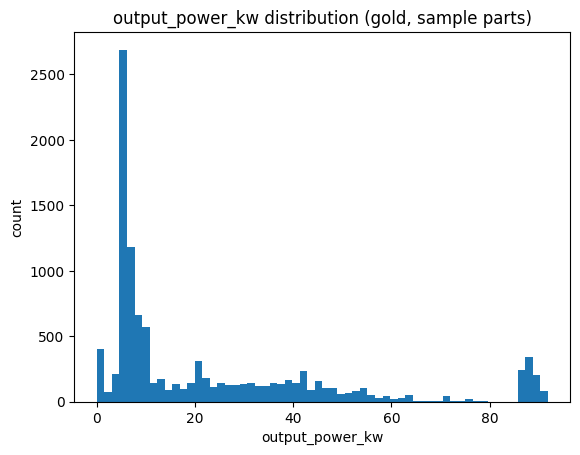

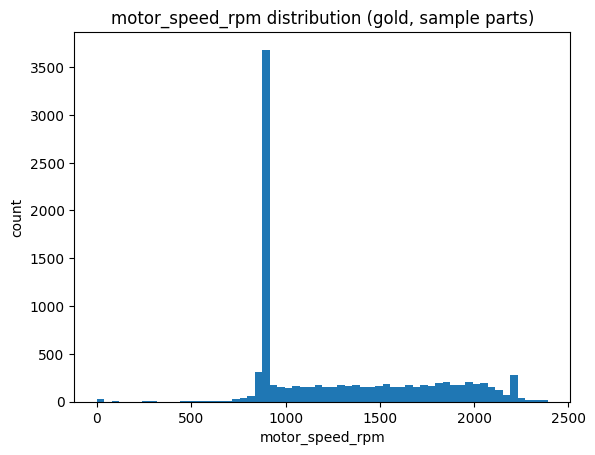

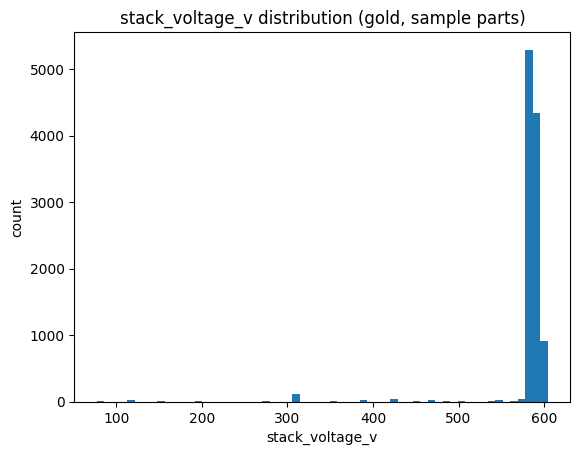

In [19]:
# Example: plot distributions for a few key signals from gold
# (Uncomment after loading df_gold above)

key_cols = ["soc_pct","battery_current_a","output_power_kw","motor_speed_rpm","stack_voltage_v"]
for c in key_cols:
    if c in df_gold.columns:
        plt.figure()
        plt.hist(df_gold[c].dropna(), bins=60)
        plt.title(f"{c} distribution (gold, sample parts)")
        plt.xlabel(c)
        plt.ylabel("count")
        plt.show()


## Export evidence tables

Use these cells to export any tables you want to share (CSV).

In [20]:
OUT = Path("models/phase3_debug/notebook_exports")
OUT.mkdir(parents=True, exist_ok=True)

# Export top suspicious rows
susp_path = OUT / "suspicious_rows_speed_nonzero_power_or_current_zero.csv"
if 'susp' in globals() and len(susp) > 0:
    susp.sort_values("abs_error", ascending=False).to_csv(susp_path, index=False)
    print("Wrote:", susp_path)

# Export per-trip summary
per_trip_path = OUT / "per_trip_summary.csv"
per_trip.to_csv(per_trip_path, index=False)
print("Wrote:", per_trip_path)


Wrote: models/phase3_debug/notebook_exports/suspicious_rows_speed_nonzero_power_or_current_zero.csv
Wrote: models/phase3_debug/notebook_exports/per_trip_summary.csv
